In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm

#####Import Ollie Tools
dirPath = "C:/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)


####Import Ollie Tools MAC
# dirPath = "/Users/olliejackson/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)

oj.thesis_plot_settings()

C:/Coding/Code
C:/Coding
Thesis plot settings applied


In [5]:

h5file = h5py.File('E:/H5/3D0meandataHLS.h5', 'r')
vels = h5file['3D0']['U100']['L100']['RPM12']

u = vels[:,:,:,0]
v = vels[:,:,:,1]
h5file.close()

u, v = oj.scaleVel(u, v, 150)
u, v = u, v
r_nd, z_nd = oj.NDUnitsForPlotsHoriz(u.shape[1], u.shape[2])

time = oj.frames_to_seconds(u, v, 150)
vort, vort_gauss = oj.calculate_vorticity(u, v)

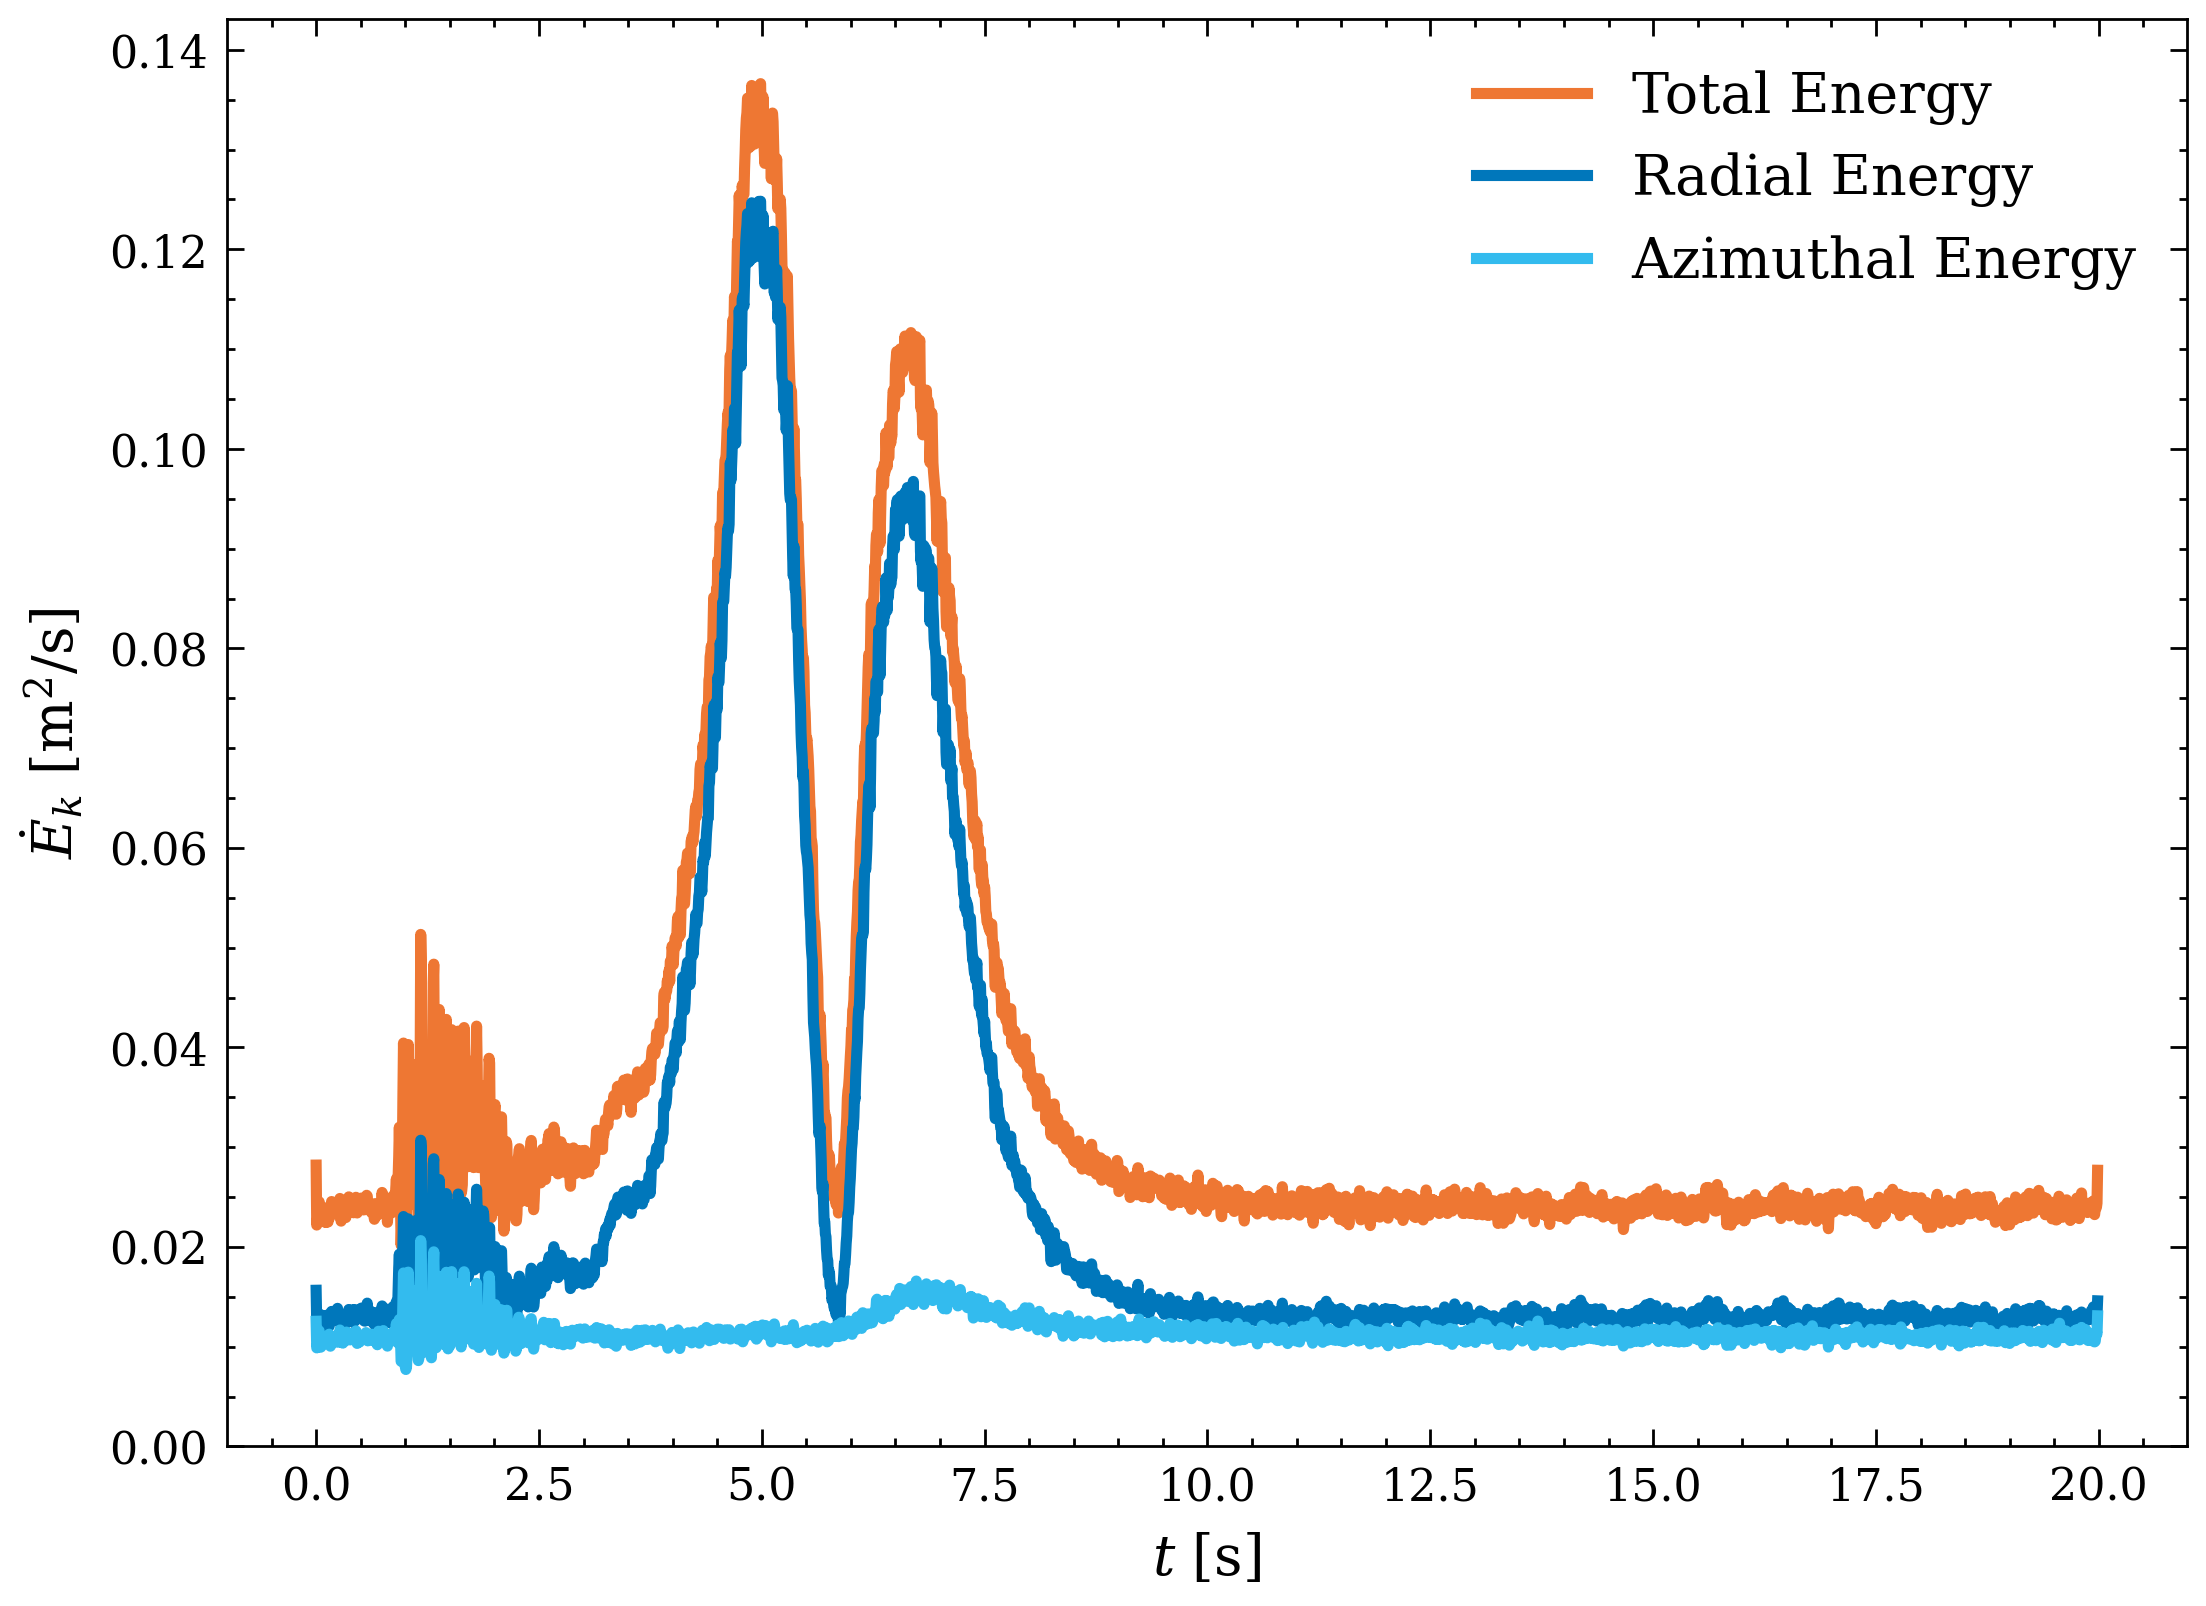

In [41]:
def sum_Velocity(u, v):
    V = np.sqrt((abs(u))**2 + (abs(v))**2)
    sum_Velocity = np.sum(V, axis=(1,2))
    # print(sum_kinetic_energy.shape)
    return sum_Velocity


def sum_VelocityR(U_r, U_az):
    sum_Velocity_Radial    = np.sum(abs(U_r), axis=(1,2))
    sum_Velocity_Azimuthal = np.sum(abs(U_az), axis=(1,2))
    return sum_Velocity_Radial, sum_Velocity_Azimuthal


h5file = h5py.File('E:/H5/3D0meandataHLS.h5', 'r')
# h5file = h5py.File('E:/H5/3D0HLSFine.h5', 'r')

RPM = ['0', '1', '2', '3', '6', '9', '12']

# vels = h5file['3D0']['U100']['L100']['RPM' + str(RPM[6])]
vels = h5file['3D0']['U100']['L100']['RPM0']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
u, v = oj.scaleVel(u, v, 150, heightPixels=1920, heightImage=1.1)

# for i in range(len(RPM[:])):
#     Revs = 'RPM' + str(RPM[i])
#     vels = h5file['3D0']['U100']['L100']['RPM' + str(RPM[1])]
#     u = vels[:,:,:,0]
#     v = vels[:,:,:,1]

V = np.sqrt(np.square(u) + np.square(v))
sV = sum_Velocity(u, v)
Ek, sEk = oj.sum_kinetic_energy(u, v)



# f1, ax1 = plt.subplots()
# ax1.plot(time, sEk)
# ax1.set_xlabel("Time [s]")
# ax1.set_ylabel("$\Sigma$ Ek")

frame = 800


xc = int(u.shape[2]/2)
yc = int(u.shape[1]/2)
x = np.linspace(0 , u.shape[2], u.shape[2])
y = np.linspace(0 , u.shape[1], u.shape[1])
X, Y = np.meshgrid(x, y) 

# r, theta, U_r, U_az, x0, y0 = oj.ConvertCylindrical(xc, yc, x, y, u[frame,:,:], v[frame,:,:])


# f2, ax2 = plt.subplots()
# cbar = ax2.contourf(U_az, cmap = "seismic")
# f2.colorbar(cbar, ax=ax2)



U_r  = np.zeros([u.shape[0], u.shape[1], u.shape[2]]) 
U_az = np.zeros([u.shape[0], u.shape[1], u.shape[2]])
for i in range(u.shape[0]):
    r, theta, U_r[i,:,:], U_az[i,:,:], x0, y0 = oj.ConvertCylindrical(xc, yc, x, y, u[i,:,:], v[i,:,:])

sU_r, sU_az = sum_VelocityR(u, v)

Ekp, sEkp = oj.sum_kinetic_energy(U_r, U_az)
EKr, Ekaz = np.sum(0.5*U_r**2, axis=(1,2)), np.sum(0.5*U_az**2, axis=(1,2))

f4, ax4 = plt.subplots()
# ax4.plot(time, sV   , label = "sV"   )
# ax4.plot(time, sU_r , label = "sU_r" )
# ax4.plot(time, sU_az, label = "sU_az")
# ax4.plot(time, sEk, label = "sEk")
ax4.plot(time, sEkp, label = "Total Energy")
ax4.plot(time, EKr, label = "Radial Energy")
ax4.plot(time, Ekaz, label = "Azimuthal Energy")
ax4.set_xlabel(r"$t$ [s]")
ax4.set_ylabel(r"$\dot{E}_{k}$ [m$^2$/s]")
ax4.set_ylim(0)
plt.legend()
plt.show()



With Rotation:

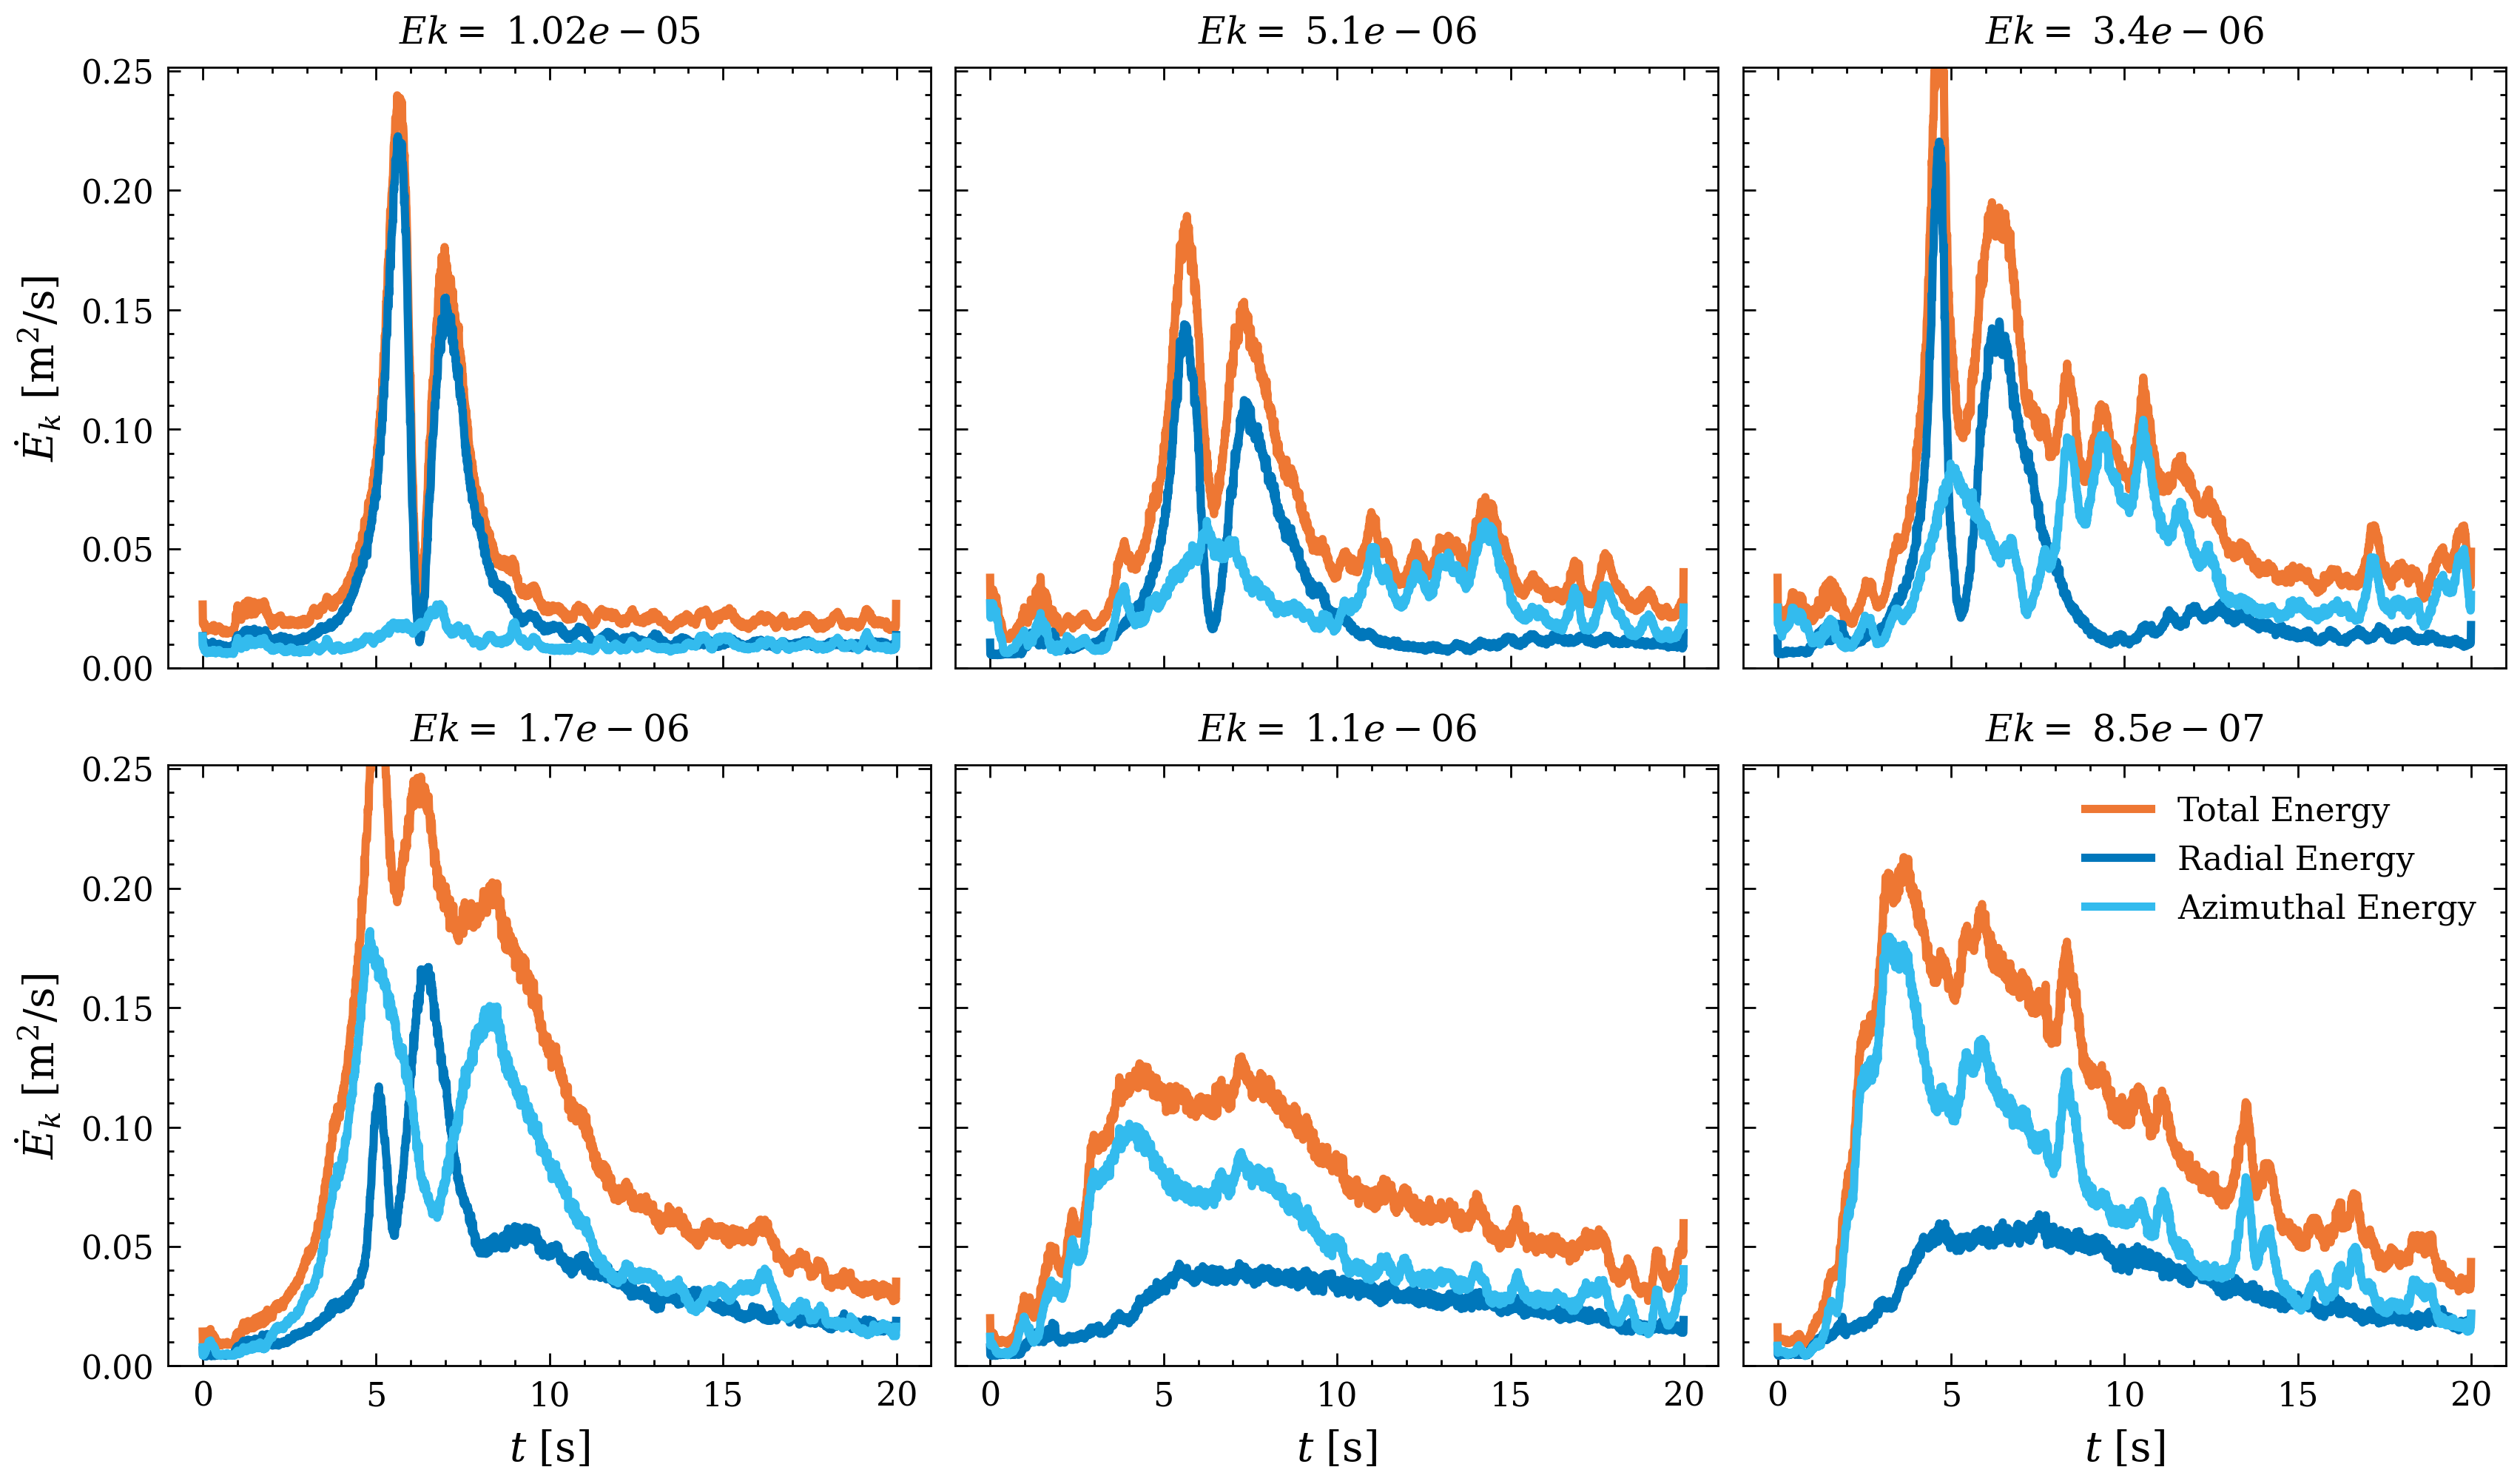

In [47]:
index = 0
rpms = [1, 2, 3, 6, 9, 12]

Eks = [0.0000102, 0.0000051, 0.0000034, 0.0000017, 0.0000011, 0.00000085]

fig, axs = plt.subplots(2, 3,sharex=True, sharey=True, figsize=(8.5, 5))

for i in range(2):
    for j in range(3):

        vels = h5file['3D0']['U100']['L100'][f'RPM{str(rpms[index])}']
        u = vels[:,:,:,0]
        v = vels[:,:,:,1]
        u, v = oj.scaleVelNozzle(u, v, 150, heightPixels=1920, heightImage=1.1) #make suer to change this for the wide fov data

        U_r  = np.zeros([u.shape[0], u.shape[1], u.shape[2]]) 
        U_az = np.zeros([u.shape[0], u.shape[1], u.shape[2]])

        for frame in range(u.shape[0]):
            r, theta, U_r[frame,:,:], U_az[frame,:,:], x0, y0 = oj.ConvertCylindrical(xc, yc, x, y, u[frame,:,:], v[frame,:,:])

        ax = axs[i, j]
        sU_r, sU_az = sum_VelocityR(u, v)

        Ekp, sEkp = oj.sum_kinetic_energy(U_r, U_az)
        EKr, Ekaz = np.sum(0.5*U_r**2, axis=(1,2)), np.sum(0.5*U_az**2, axis=(1,2))

        
        # colorGen = cmap1(int(frame) / 540)
        ax.plot(time, sEkp, label = "Total Energy")
        ax.plot(time, EKr, label = "Radial Energy")
        ax.plot(time, Ekaz, label = "Azimuthal Energy")
        ax.set_title(f"$Ek = ~{Eks[index]}$", size=9)
        ax.set_ylim(0)
        index += 1

axs[0, 0].set_ylabel(r"$\dot{E}_{k}$ [m$^2$/s]")
axs[1, 0].set_ylabel(r"$\dot{E}_{k}$ [m$^2$/s]")
axs[1, 0].set_xlabel(r"$t$ [s]")
axs[1, 1].set_xlabel(r"$t$ [s]")
axs[1, 2].set_xlabel(r"$t$ [s]")
axs[1, 2].legend(fontsize=8)
plt.legend(fontsize=8)
plt.show()

Peak Energy Against Rotation Rate

Matplotlib Default Colors - how2matplotlib.com:
#EE7733
#0077BB
#33BBEE
#EE3377
#CC3311
#009988
#BBBBBB


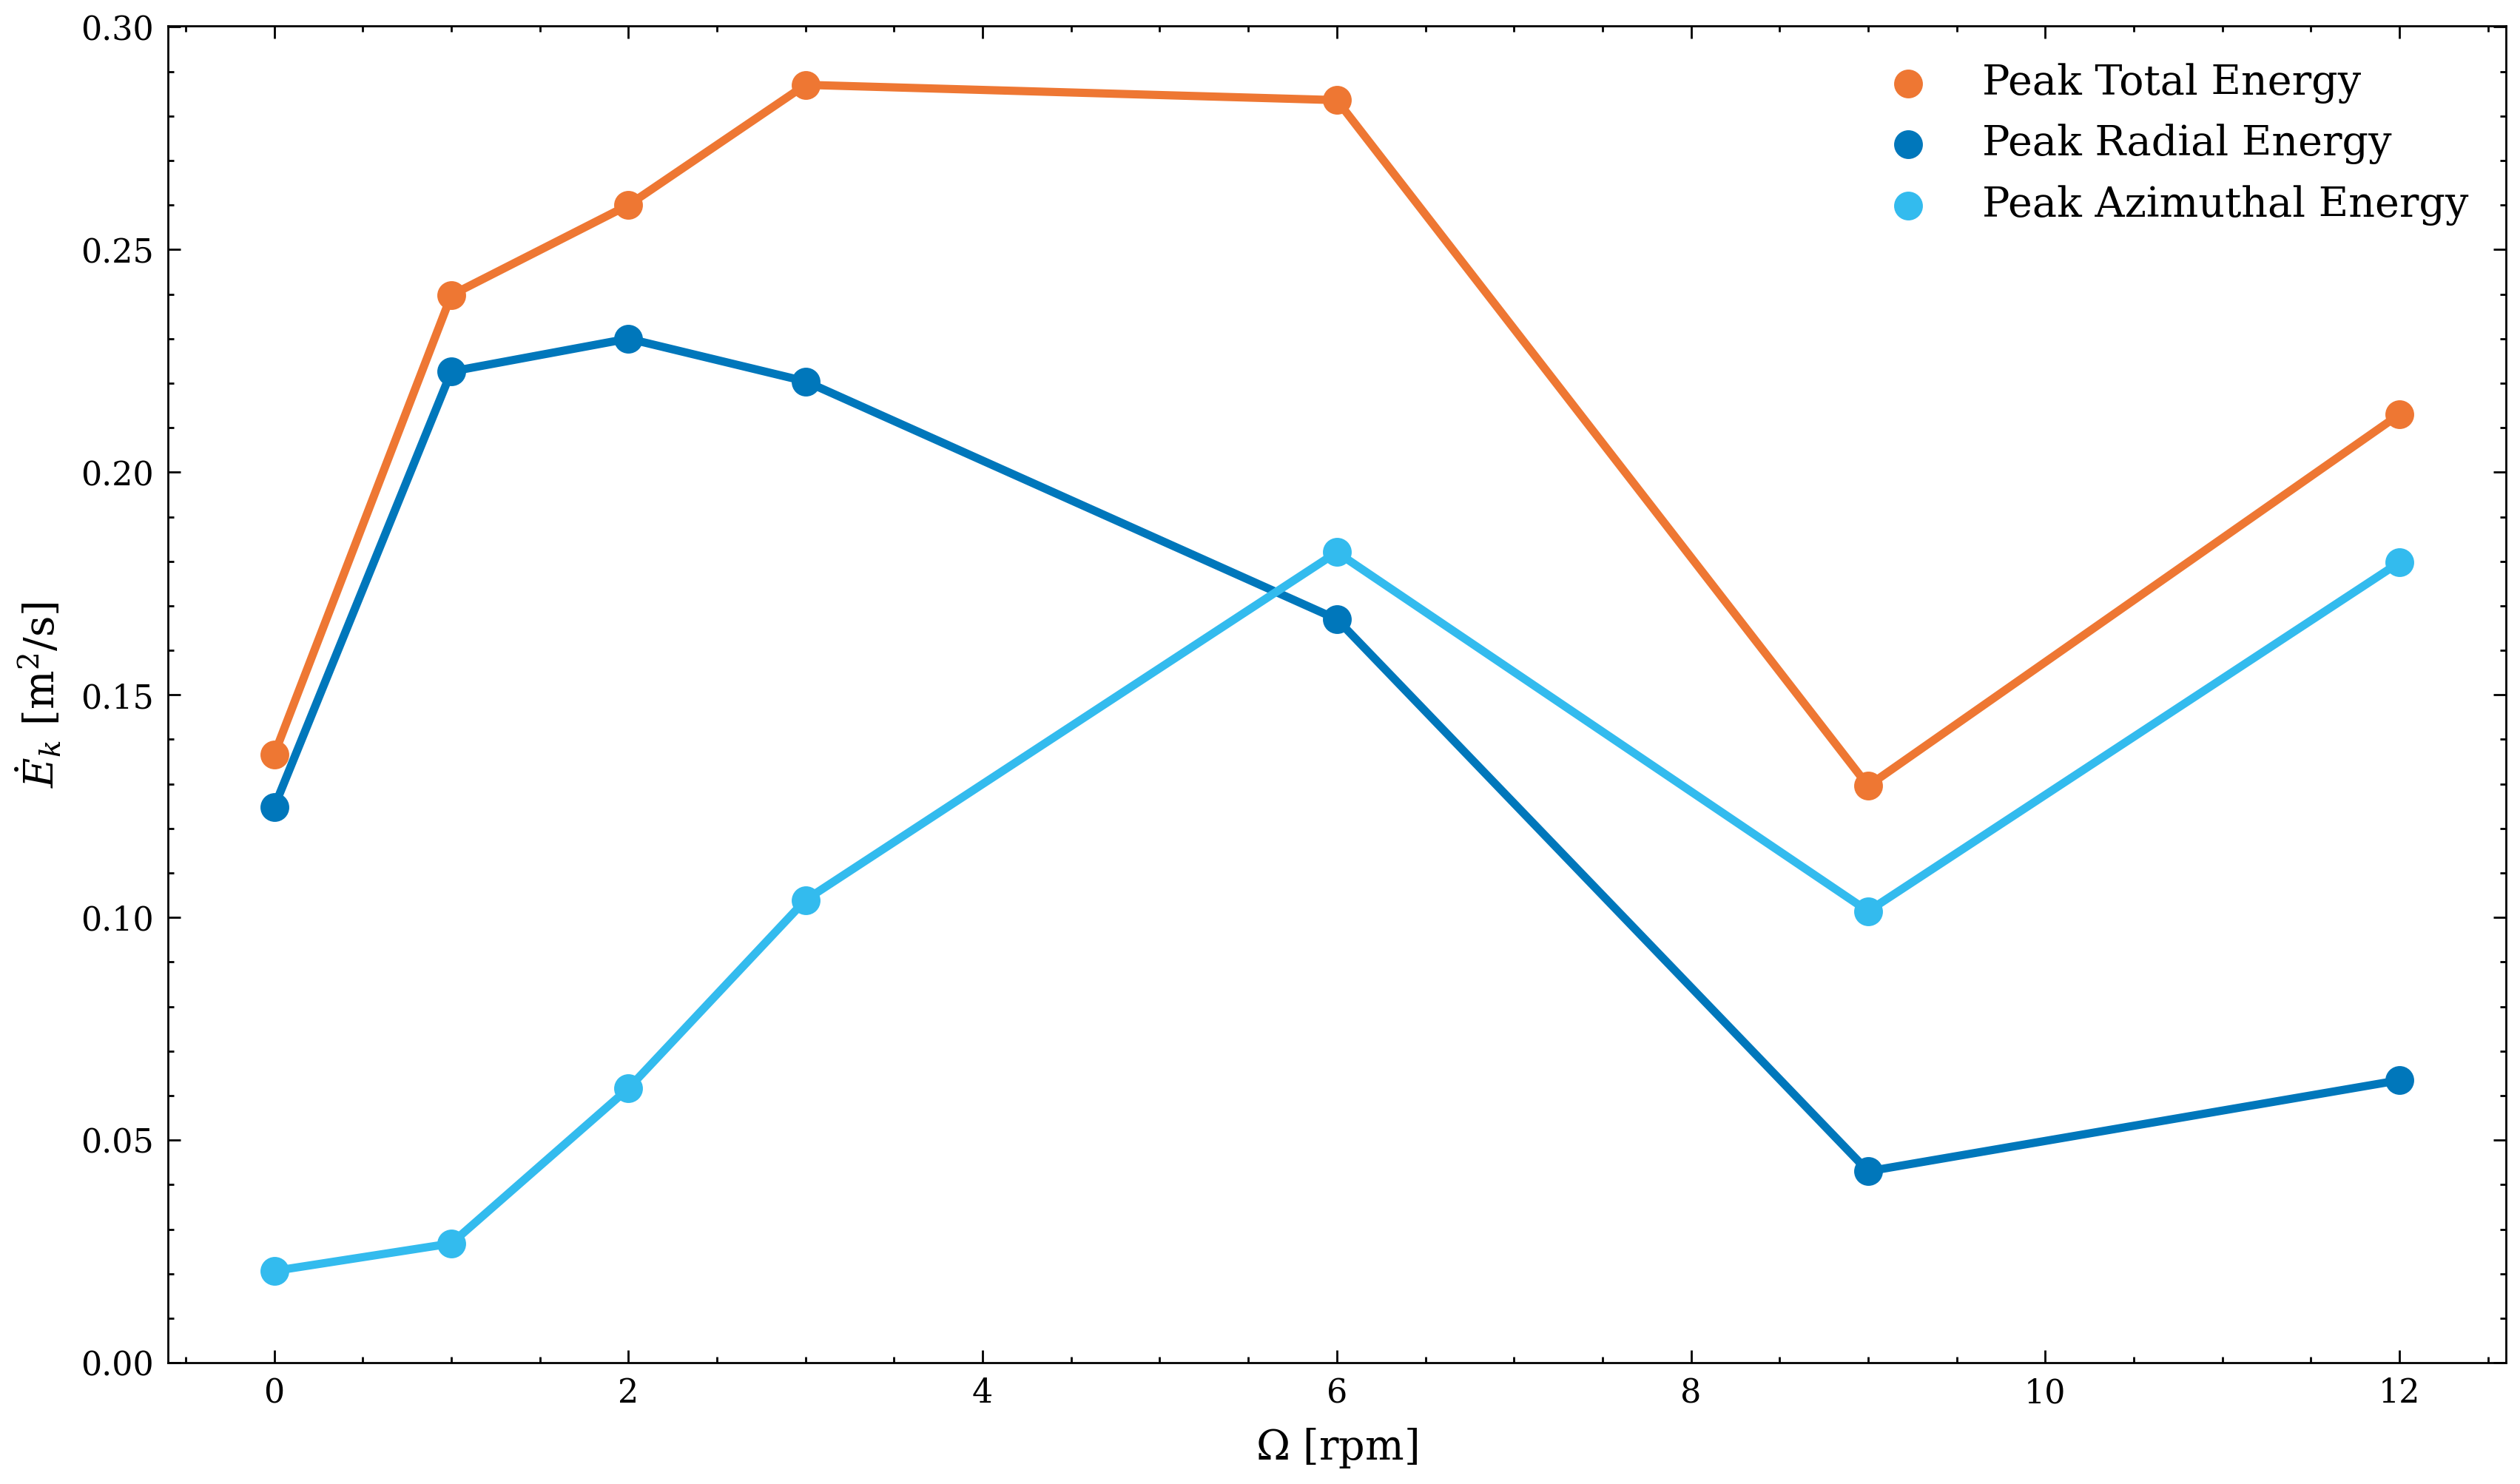

In [66]:
rpms = [0, 1, 2, 3, 6, 9, 12]

Eks = [0.0000102, 0.0000051, 0.0000034, 0.0000017, 0.0000011, 0.00000085]

fig, ax = plt.subplots(1, 1,sharex=True, sharey=True, figsize=(8.5, 5))

color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Print the default colors
print("Matplotlib Default Colors - how2matplotlib.com:")
for color in color_cycle:
    print(color)

peak   = np.zeros(len(rpms))
peakr  = np.zeros(len(rpms))
peakaz = np.zeros(len(rpms))

for i in range(len(rpms)):

    vels = h5file['3D0']['U100']['L100'][f'RPM{str(rpms[i])}']
    u = vels[:,:,:,0]
    v = vels[:,:,:,1]
    u, v = oj.scaleVelNozzle(u, v, 150, heightPixels=1920, heightImage=1.1) #make suer to change this for the wide fov data
    U_r  = np.zeros([u.shape[0], u.shape[1], u.shape[2]]) 
    U_az = np.zeros([u.shape[0], u.shape[1], u.shape[2]])
    for frame in range(u.shape[0]):
        r, theta, U_r[frame,:,:], U_az[frame,:,:], x0, y0 = oj.ConvertCylindrical(xc, yc, x, y, u[frame,:,:], v[frame,:,:])

    sU_r, sU_az = sum_VelocityR(u, v)
    Ekp, sEkp = oj.sum_kinetic_energy(U_r, U_az)
    EKr, Ekaz = np.sum(0.5*U_r**2, axis=(1,2)), np.sum(0.5*U_az**2, axis=(1,2))
    peak[i]  = np.max(sEkp)
    peakr[i] = np.max(EKr)
    peakaz[i]= np.max(Ekaz)

    # colorGen = cmap1(int(frame) / 540)
    # ax.scatter(rpms[i], peak,   color='#EE7733' )
    # ax.scatter(rpms[i], peakr,  color='#0077BB' )
    # ax.scatter(rpms[i], peakaz, color='#33BBEE' )
    # ax.set_ylim(0)


peak[2]   = 0.26
peakr[2]  = 0.23
# peakaz = 

ax.scatter(rpms, peak,   color='#EE7733', label = "Peak Total Energy")
ax.scatter(rpms, peakr,  color='#0077BB', label = "Peak Radial Energy")
ax.scatter(rpms, peakaz, color='#33BBEE', label = "Peak Azimuthal Energy")
ax.plot(rpms, peak,   color='#EE7733')
ax.plot(rpms, peakr,  color='#0077BB')
ax.plot(rpms, peakaz, color='#33BBEE')

ax.set_xlabel(r"$\Omega$ [rpm]")
ax.set_ylabel(r"$\dot{E}_{k}$ [m$^2$/s]")
ax.set_ylim(0)
plt.legend()